In [12]:
import pandas as pd

In [13]:
df = pd.read_csv("dataset_clinica_20261.csv", encoding="utf-8")

def corrigir_mojibake(valor):
    if isinstance(valor, str) and ("Ã" in valor or "Â" in valor):
        try:
            return valor.encode("latin1").decode("utf-8")
        except UnicodeError:
            return valor
    return valor

colunas_texto = df.select_dtypes(include="object").columns
df[colunas_texto] = df[colunas_texto].apply(lambda col: col.map(corrigir_mojibake))

df.head()

,cd_processo,id_processo,classe,assunto,magistrado,comarca,foro,vara,data_disponibilizacao,decisao
0,5B0005D030000,1002017-64.2024.8.26.0191,Procedimento do Juizado Especial Cível,Bancários,LUCIANA DO CARMO NOGUEIRA,Ferraz de Vasconcelos,Foro de Ferraz de Vasconcelos,Vara do Juizado Especial Cível e Criminal,27/08/2024,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...
1,03001EPSV0000,1034196-67.2023.8.26.0003,Procedimento Comum Cível,Bancários,Laura Mota Lima de Oliveira Baccin,SÃO PAULO,Foro Regional III - Jabaquara,1ª Vara Cível,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...
2,I20002VT10000,1000247-51.2023.8.26.0650,Procedimento Comum Cível,Empréstimo consignado,Marcia Yoshie Ishikawa,Valinhos,Foro de Valinhos,3ª Vara,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1000247-51.2...
3,DE000DZ0N0000,1010110-16.2024.8.26.0482,Procedimento Comum Cível,Bancários,Leonardo Mazzilli Marcondes,Presidente Prudente,Foro de Presidente Prudente,4ª Vara Cível,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...
4,2S001VMCT0000,1101723-02.2024.8.26.0100,Procedimento Comum Cível,Bancários,MICHELLE FABIOLA DITTERT PUPULIM,SÃO PAULO,Foro Regional III - Jabaquara,6ª Vara Cível,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1101723-02.2...


In [14]:
df.columns

Index(['cd_processo', 'id_processo', 'classe', 'assunto', 'magistrado',
       'comarca', 'foro', 'vara', 'data_disponibilizacao', 'decisao'],
      dtype='object')

In [15]:
# Padroniza os nomes de magistrado em maiúsculas
df["magistrado"] = df["magistrado"].astype(str).str.strip().str.upper()

# Defina um nome para filtrar (ex.: "LUCIANA DO CARMO NOGUEIRA") ou deixe None
magistrado_filtro = None

if magistrado_filtro:
    df_filtrado = df[df["magistrado"].str.contains(magistrado_filtro.upper(), na=False)]
else:
    df_filtrado = df

coluna_assunto = "assunto" if "assunto" in df_filtrado.columns else "assuntos"
colunas_para_analisar = ["classe", coluna_assunto, "foro", "vara", "magistrado"]

for coluna in colunas_para_analisar:
    print(f"\n=== value_counts: {coluna} ===")
    print(df_filtrado[coluna].value_counts(dropna=False))


=== value_counts: classe ===
classe
Procedimento Comum Cível                                          16652
Procedimento do Juizado Especial Cível                             4053
Cumprimento de sentença                                            1766
Cumprimento Provisório de Sentença                                   99
Ação de Exigir Contas                                                84
Produção Antecipada da Prova                                         50
Procedimento de Repactuação de Dívidas (Superendividamento)          33
Tutela Antecipada Antecedente                                        29
Tutela Cautelar Antecedente                                          15
Cumprimento Provisório de Decisão                                    14
Liquidação de Sentença pelo Procedimento Comum                       13
Embargos à Execução                                                  12
NaN                                                                  10
Liquidação por Arbitramento

In [16]:
coluna_decisao = "decisao"
coluna_processo = "id_processo" if "id_processo" in df.columns else None

top10 = df[[coluna_decisao]].head(10).copy()
if coluna_processo:
    top10.insert(0, coluna_processo, df[coluna_processo].head(10).values)

linhas = []
for i, (_, row) in enumerate(top10.iterrows(), start=1):
    if coluna_processo:
        linhas.append(f"Processo {i} - {row[coluna_processo]}")
    else:
        linhas.append(f"Processo {i}")
    linhas.append(str(row[coluna_decisao]))
    linhas.append("-" * 80)

texto_saida = "\n".join(linhas)
arquivo_saida = "top10_decisoes.txt"

with open(arquivo_saida, "w", encoding="utf-8") as f:
    f.write(texto_saida)

print(f"Arquivo salvo: {arquivo_saida}")

Arquivo salvo: top10_decisoes.txt


In [17]:
import re
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

padrao_justica_gratuita = re.compile(
    r"\b("
    r"justica\s+gratuita|"
    r"gratuidade\s+da\s+justica|"
    r"beneficio\s+da\s+justica\s+gratuita|"
    r"assistencia\s+judiciaria\s+gratuita|"
    r"ajg"
    r")\b",
    flags=re.IGNORECASE,
 )

coluna_flag = "tem_justica_gratuita"
mascara_justica_gratuita = df["decisao"].apply(
    lambda x: bool(padrao_justica_gratuita.search(normalizar_texto(x)))
 )

if coluna_flag in df.columns:
    df[coluna_flag] = mascara_justica_gratuita
else:
    posicao = df.columns.get_loc("magistrado") + 1 if "magistrado" in df.columns else len(df.columns)
    df.insert(posicao, coluna_flag, mascara_justica_gratuita)

df[["magistrado", coluna_flag, "decisao"]].head(10)

,magistrado,tem_justica_gratuita,decisao
0,LUCIANA DO CARMO NOGUEIRA,True,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...
1,LAURA MOTA LIMA DE OLIVEIRA BACCIN,True,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...
2,MARCIA YOSHIE ISHIKAWA,False,SENTENÇA\n\nProcesso Digital nº:\t1000247-51.2...
3,LEONARDO MAZZILLI MARCONDES,True,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...
4,MICHELLE FABIOLA DITTERT PUPULIM,False,SENTENÇA\n\nProcesso Digital nº:\t1101723-02.2...
5,ALÉSSIO MARTINS GONÇALVES,False,SENTENÇA\n\nProcesso nº:\t1009437-72.2023.8.26...
6,VINICIUS RODRIGUES VIEIRA,False,Processo nº:\t0067587-64.2009.8.26.0506\nClass...
7,JOANNA TERRA SAMPAIO DOS SANTOS,False,SENTENÇA\n\nProcesso nº:\t1023563-21.2024.8.26...
8,MÔNICA DE CASSIA THOMAZ PEREZ REIS LOBO,False,SENTENÇA\n\nProcesso nº:\t1101899-78.2024.8.26...
9,MELISSA BERTOLUCCI,False,SENTENÇA\n\nProcesso Digital nº:\t1120452-76.2...


In [18]:
print(df_filtrado["tem_justica_gratuita"].value_counts(dropna=False))

tem_justica_gratuita
True     12434
False    10432
Name: count, dtype: int64


In [19]:
coluna_assunto = "assunto" if "assunto" in df.columns else "assuntos"
coluna_flag = "tem_justica_gratuita"

# Tabela por assunto x justiça gratuita
resumo_assunto = pd.crosstab(df[coluna_assunto], df[coluna_flag], dropna=False)
resumo_assunto = resumo_assunto.rename(columns={False: "nao", True: "sim"})

# Garante as colunas mesmo se uma categoria não aparecer
for c in ["sim", "nao"]:
    if c not in resumo_assunto.columns:
        resumo_assunto[c] = 0

resumo_assunto["total"] = resumo_assunto["sim"] + resumo_assunto["nao"]
resumo_assunto["pct_sim"] = (resumo_assunto["sim"] / resumo_assunto["total"] * 100).round(2)
resumo_assunto = resumo_assunto.sort_values(["sim", "total"], ascending=False)

print("Resumo por assunto (justiça gratuita: sim/nao):")
display(resumo_assunto.head(30))

print("\nAssuntos com pelo menos 1 ocorrência de JUSTIÇA GRATUITA:")
display(resumo_assunto[resumo_assunto["sim"] > 0].head(30))

print("\nAssuntos sem ocorrência de JUSTIÇA GRATUITA:")
display(resumo_assunto[resumo_assunto["sim"] == 0].head(30))

Resumo por assunto (justiça gratuita: sim/nao):


tem_justica_gratuita,nao,sim,total,pct_sim
assunto,,,,
Bancários,8502,8872,17374,51.06
Empréstimo consignado,1435,2969,4404,67.42
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",273,336,609,55.17
Crédito Direto ao Consumidor - CDC,108,128,236,54.24
Tarifas,102,121,223,54.26
Crédito Rotativo,12,8,20,40.00



Assuntos com pelo menos 1 ocorrência de JUSTIÇA GRATUITA:


tem_justica_gratuita,nao,sim,total,pct_sim
assunto,,,,
Bancários,8502,8872,17374,51.06
Empréstimo consignado,1435,2969,4404,67.42
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",273,336,609,55.17
Crédito Direto ao Consumidor - CDC,108,128,236,54.24
Tarifas,102,121,223,54.26
Crédito Rotativo,12,8,20,40.00



Assuntos sem ocorrência de JUSTIÇA GRATUITA:


tem_justica_gratuita,nao,sim,total,pct_sim
assunto,,,,


In [20]:
coluna_assunto = "assunto" if "assunto" in df.columns else "assuntos"
coluna_flag = "tem_justica_gratuita"

# Tabela cruzada normalizada pelas colunas (sim/nao)
# Isso calculará a proporção de cada assunto DENTRO do universo dos que pediram (sim) e dos que não pediram (nao)
resumo_assunto_norm = pd.crosstab(df[coluna_assunto], df[coluna_flag], normalize='columns', dropna=False)
resumo_assunto_norm = resumo_assunto_norm.rename(columns={False: "pct_nao", True: "pct_sim"})

# Converte proporção para porcentagem
resumo_assunto_norm = (resumo_assunto_norm * 100).round(2)

# Garante as colunas caso o dataset fosse 100% sim ou não
for c in ["pct_sim", "pct_nao"]:
    if c not in resumo_assunto_norm.columns:
        resumo_assunto_norm[c] = 0.0

# Calcula a diferença percentual entre os dois grupos
resumo_assunto_norm["diferenca_pct (sim - nao)"] = resumo_assunto_norm["pct_sim"] - resumo_assunto_norm["pct_nao"]

resumo_assunto_norm = resumo_assunto_norm.sort_values("pct_sim", ascending=False)

print("Percentual de cada assunto dentro de cada grupo (Justiça Gratuita: SIM vs NÃO):")
display(resumo_assunto_norm.head(30))

print("\nAssuntos com maior prevalência NO GRUPO SIM em comparação ao GRUPO NÃO (maior assimetria para o sim):")
display(resumo_assunto_norm.sort_values("diferenca_pct (sim - nao)", ascending=False).head(20))

print("\nAssuntos com maior prevalência NO GRUPO NÃO em comparação ao GRUPO SIM:")
display(resumo_assunto_norm.sort_values("diferenca_pct (sim - nao)", ascending=True).head(20))

Percentual de cada assunto dentro de cada grupo (Justiça Gratuita: SIM vs NÃO):


tem_justica_gratuita,pct_nao,pct_sim,diferenca_pct (sim - nao)
assunto,,,
Bancários,81.50,71.35,-10.15
Empréstimo consignado,13.76,23.88,10.12
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",2.62,2.70,0.08
Crédito Direto ao Consumidor - CDC,1.04,1.03,-0.01
Tarifas,0.98,0.97,-0.01
Crédito Rotativo,0.12,0.06,-0.06



Assuntos com maior prevalência NO GRUPO SIM em comparação ao GRUPO NÃO (maior assimetria para o sim):


tem_justica_gratuita,pct_nao,pct_sim,diferenca_pct (sim - nao)
assunto,,,
Empréstimo consignado,13.76,23.88,10.12
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",2.62,2.70,0.08
Tarifas,0.98,0.97,-0.01
Crédito Direto ao Consumidor - CDC,1.04,1.03,-0.01
Crédito Rotativo,0.12,0.06,-0.06
Bancários,81.50,71.35,-10.15



Assuntos com maior prevalência NO GRUPO NÃO em comparação ao GRUPO SIM:


tem_justica_gratuita,pct_nao,pct_sim,diferenca_pct (sim - nao)
assunto,,,
Bancários,81.50,71.35,-10.15
Crédito Rotativo,0.12,0.06,-0.06
Tarifas,0.98,0.97,-0.01
Crédito Direto ao Consumidor - CDC,1.04,1.03,-0.01
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",2.62,2.70,0.08
Empréstimo consignado,13.76,23.88,10.12


In [21]:
# Padrão regex para capturar o resultado da sentença
# Procura conjugações de "julgar" seguido (até 80 caracteres de distância) do resultado
padrao_resultado = re.compile(
    r"\b(?:julgo|julga|julgam|julgado|julgada|julgar|julgo-o)\b" # Variações do verbo julgar
    r".{0,80}?" # Permite algumas palavras no meio (ex: 'o pedido inicial', 'liminarmente', 'totalmente', etc)
    r"\b(parcialmente procedente|parcialmente improcedente|totalmente procedente|totalmente improcedente|procedente|improcedente|extinto)\b",
    flags=re.IGNORECASE
)

def extrair_resultado(texto):
    if pd.isna(texto):
        return "nao_identificado"
    
    # normalizar_texto foi definida na célula de justiça gratuita
    texto_norm = normalizar_texto(texto) 
    
    match = padrao_resultado.search(texto_norm)
    if match:
        # Pega a palavra/expressão capturada e troca espaço por underline
        resultado = match.group(1).strip().replace(" ", "_").lower()
        return resultado
        
    return "nao_identificado"

coluna_decisao = "decisao"
coluna_resultado = "resultado_sentenca"

if coluna_decisao in df.columns:
    # Aplica a função para criar a nova coluna no DataFrame
    df[coluna_resultado] = df[coluna_decisao].apply(extrair_resultado)
    
    print("Distribuição dos resultados extraídos:")
    print(df[coluna_resultado].value_counts(dropna=False))
    
    print("\nAmostra de decisões e os resultados extraídos:")
    # Filtra alguns casos onde identificou algo para mostrar de exemplo
    df_exemplo = df[df[coluna_resultado] != "nao_identificado"]
    if not df_exemplo.empty:
        display(df_exemplo[[coluna_decisao, coluna_resultado]].head(10))
    else:
        display(df[[coluna_decisao, coluna_resultado]].head(10))
else:
    print(f"Coluna '{coluna_decisao}' não encontrada para aplicar a extração.")

Distribuição dos resultados extraídos:
resultado_sentenca
nao_identificado             7336
extinto                      6797
improcedente                 4625
procedente                   2092
parcialmente_procedente      1955
totalmente_procedente          36
totalmente_improcedente        21
parcialmente_improcedente       4
Name: count, dtype: int64

Amostra de decisões e os resultados extraídos:


,decisao,resultado_sentenca
0,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...,extinto
1,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...,improcedente
3,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...,procedente
5,SENTENÇA\n\nProcesso nº:\t1009437-72.2023.8.26...,parcialmente_procedente
6,Processo nº:\t0067587-64.2009.8.26.0506\nClass...,extinto
7,SENTENÇA\n\nProcesso nº:\t1023563-21.2024.8.26...,extinto
9,SENTENÇA\n\nProcesso Digital nº:\t1120452-76.2...,extinto
10,SENTENÇA\nProcesso nº:\t1011520-08.2024.8.26.0...,extinto
11,SENTENÇA\n\nProcesso Digital nº:\t0014038-08.2...,extinto
12,SENTENÇA\n\nProcesso Digital nº:\t1057594-09.2...,extinto


=== 1. Informações Gerais do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22866 entries, 0 to 22865
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   cd_processo            22866 non-null  object
 1   id_processo            22866 non-null  object
 2   classe                 22856 non-null  object
 3   assunto                22866 non-null  object
 4   magistrado             22866 non-null  object
 5   tem_justica_gratuita   22866 non-null  bool  
 6   comarca                22866 non-null  object
 7   foro                   22866 non-null  object
 8   vara                   22866 non-null  object
 9   data_disponibilizacao  22866 non-null  object
 10  decisao                22866 non-null  object
 11  resultado_sentenca     22866 non-null  object
dtypes: bool(1), object(11)
memory usage: 1.9+ MB


None


=== 2. Valores Ausentes no Dataset ===


classe    10
dtype: int64


=== 3. Análise Univariada - Gráficos de Barra (Top 10 Categorias) ===


C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


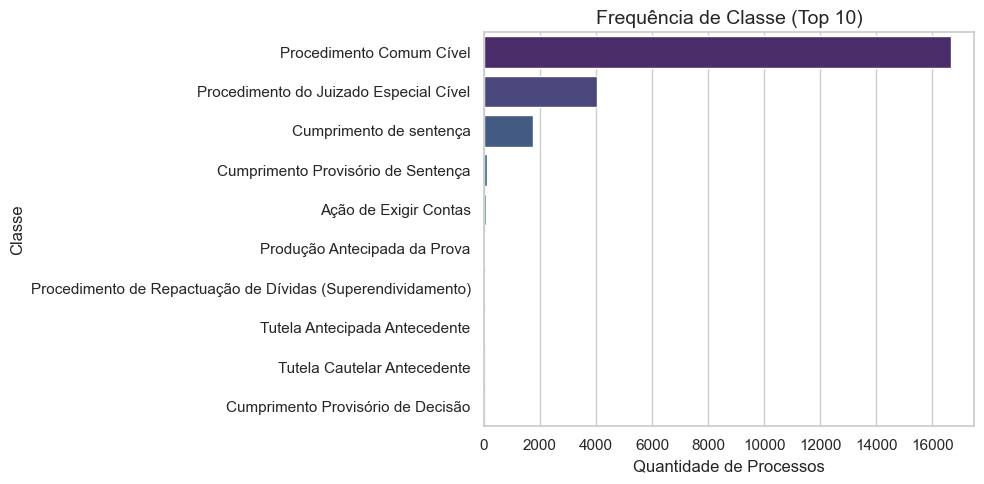

C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


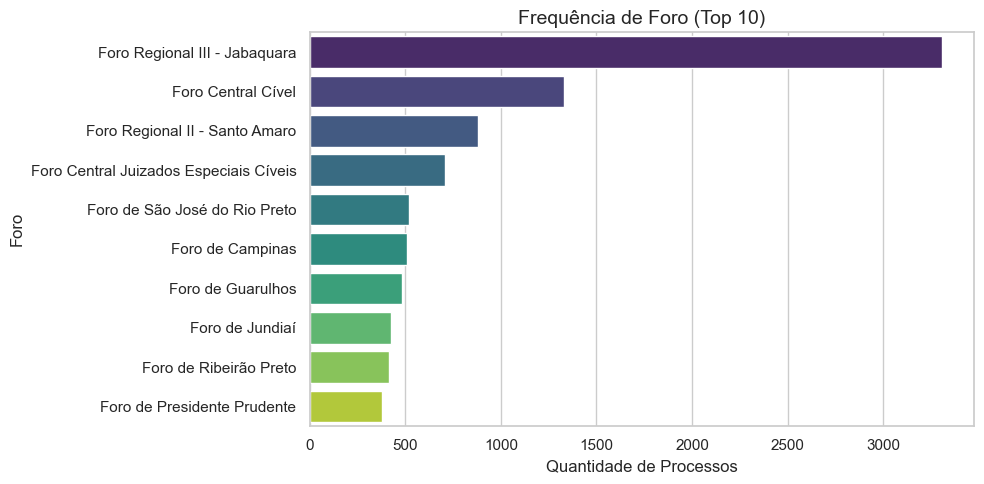

C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


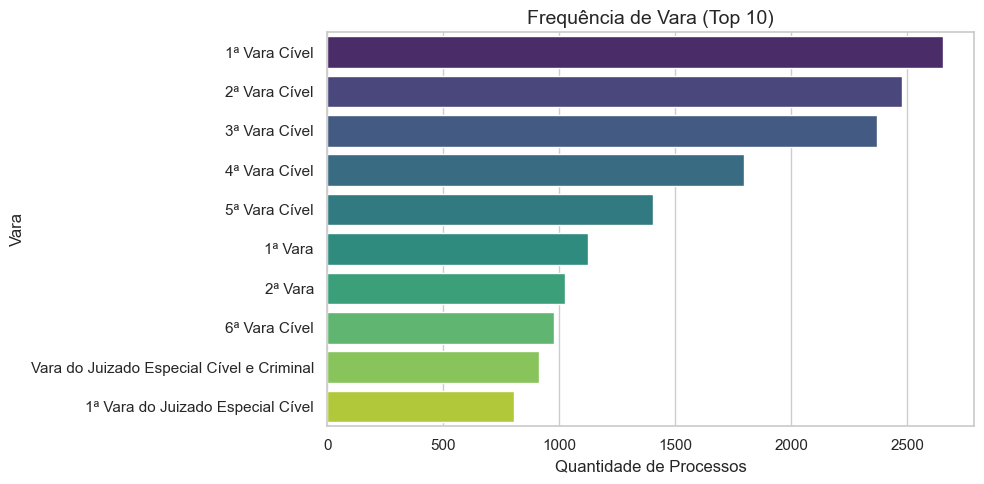

C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


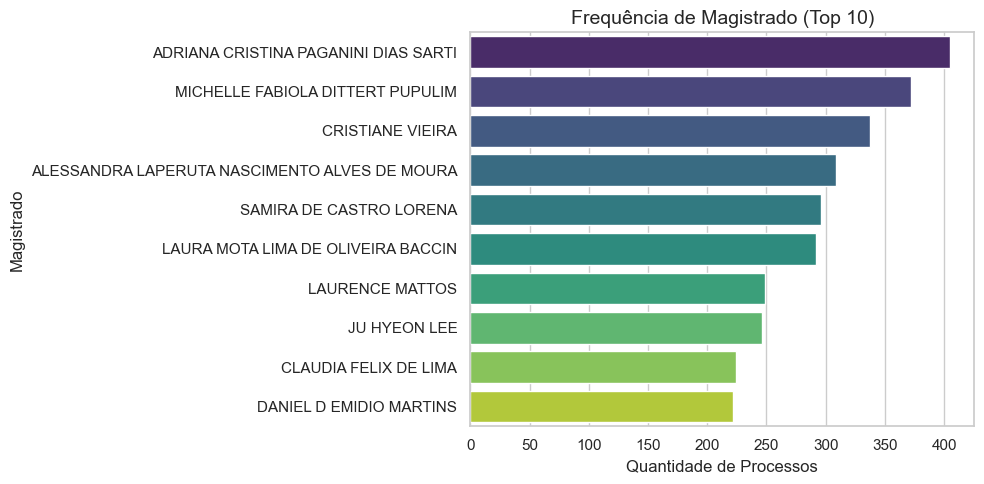

C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


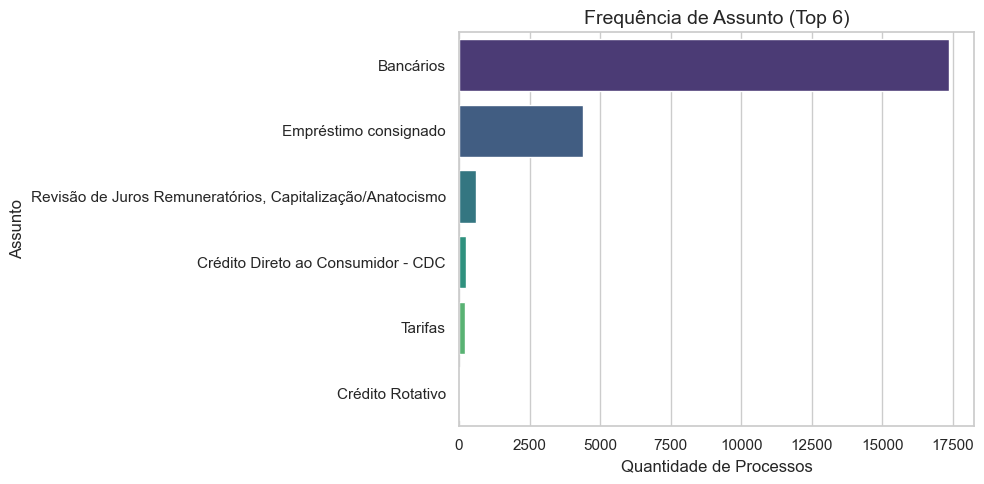

C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


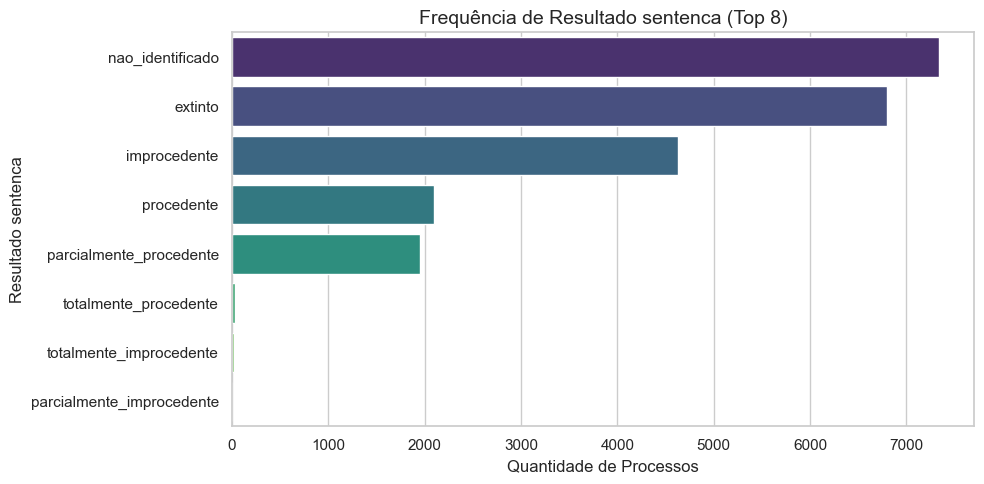

C:\Users\danil\AppData\Local\Temp\ipykernel_19196\1331237129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")


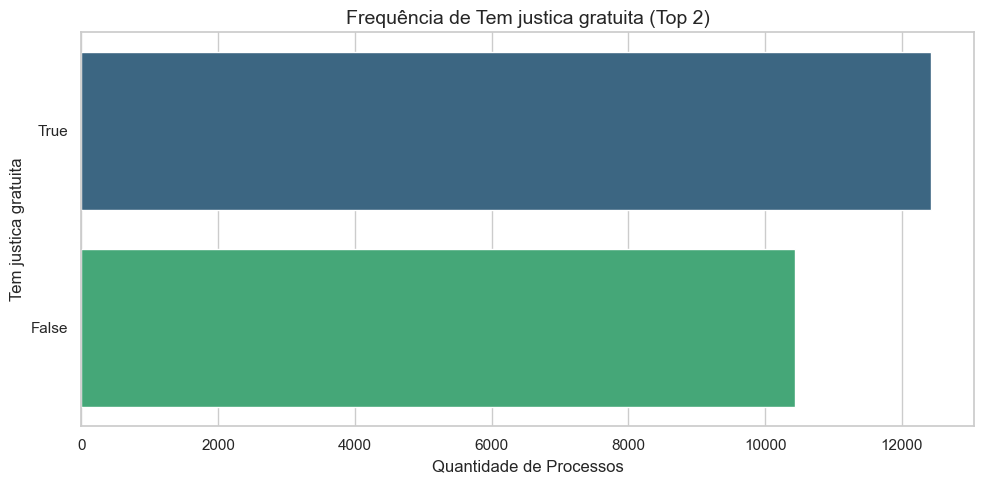


=== 4. Análise Bivariada - Resultado da Sentença x Justiça Gratuita ===


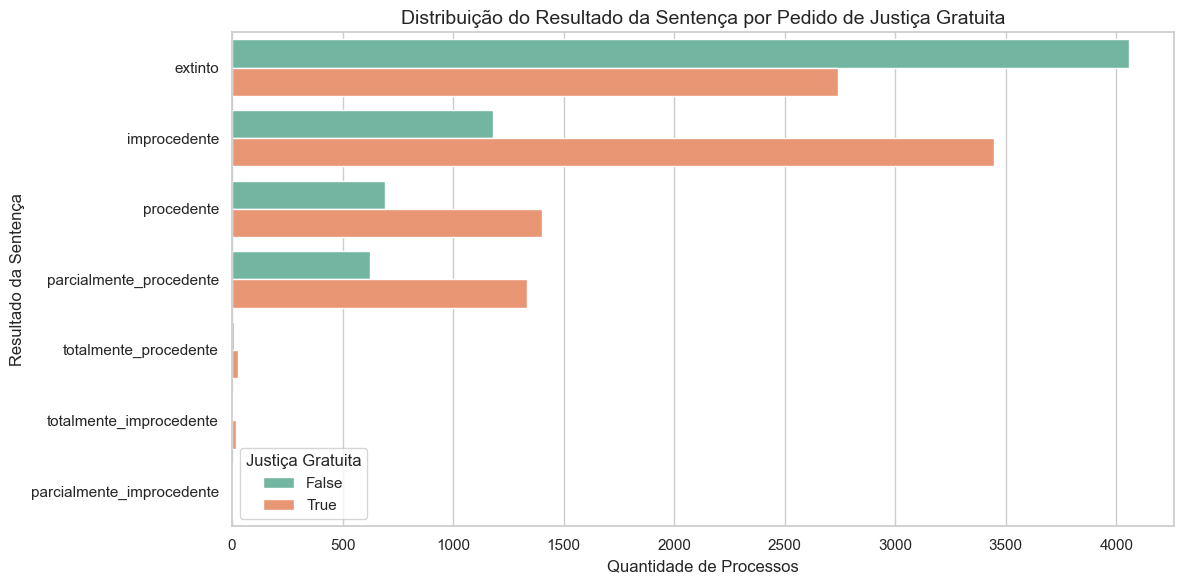


=== 5. Análise de Variáveis Numéricas (Boxplots e Histogramas) ===
Nenhuma variável numérica contínua (como 'valor_da_causa') foi encontrada no dataframe para plotagem de Boxplots e Histogramas.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid")

print("=== 1. Informações Gerais do Dataset ===")
display(df.info())

print("\n=== 2. Valores Ausentes no Dataset ===")
valores_nulos = df.isnull().sum()
display(valores_nulos[valores_nulos > 0])

# Define as colunas categóricas que sabemos que existem no dataset
colunas_cat = ["classe", "foro", "vara", "magistrado"]
coluna_assunto = "assunto" if "assunto" in df.columns else "assuntos"
colunas_cat.append(coluna_assunto)

if "resultado_sentenca" in df.columns:
    colunas_cat.append("resultado_sentenca")

if "tem_justica_gratuita" in df.columns:
    colunas_cat.append("tem_justica_gratuita")

print("\n=== 3. Análise Univariada - Gráficos de Barra (Top 10 Categorias) ===")
# Para variáveis categóricas, fazemos contagem
for col in colunas_cat:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        
        # Para justiça gratuita, mostrar todos (só 2 valores). Para os outros, top 10
        if col == "tem_justica_gratuita":
            data_plot = df[col].value_counts()
        else:
            data_plot = df[col].value_counts().head(10)
            
        sns.barplot(y=data_plot.index.astype(str), x=data_plot.values, palette="viridis")
        plt.title(f"Frequência de {col.replace('_', ' ').capitalize()} (Top {len(data_plot)})", fontsize=14)
        plt.xlabel("Quantidade de Processos")
        plt.ylabel(col.replace('_', ' ').capitalize())
        plt.tight_layout()
        plt.show()

print("\n=== 4. Análise Bivariada - Resultado da Sentença x Justiça Gratuita ===")
if "tem_justica_gratuita" in df.columns and "resultado_sentenca" in df.columns:
    plt.figure(figsize=(12, 6))
    # Filtramos 'nao_identificado' para facilitar a visualização se houver muitos
    df_plot = df[df["resultado_sentenca"] != "nao_identificado"]
    
    sns.countplot(
        data=df_plot, 
        y="resultado_sentenca", 
        hue="tem_justica_gratuita", 
        order=df_plot["resultado_sentenca"].value_counts().index,
        palette="Set2"
    )
    plt.title("Distribuição do Resultado da Sentença por Pedido de Justiça Gratuita", fontsize=14)
    plt.xlabel("Quantidade de Processos")
    plt.ylabel("Resultado da Sentença")
    plt.legend(title="Justiça Gratuita")
    plt.tight_layout()
    plt.show()


print("\n=== 5. Análise de Variáveis Numéricas (Boxplots e Histogramas) ===")
# Identifica colunas estritamente numéricas (excluindo IDs)
cols_numericas = df.select_dtypes(include=["int64", "float64"]).columns
cols_numericas = [c for c in cols_numericas if "id" not in c.lower() and c not in ["tem_justica_gratuita"]]

if len(cols_numericas) > 0:
    display(df[cols_numericas].describe())
    
    for col in cols_numericas:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        
        # Histograma com KDE para ver a distribuição
        sns.histplot(df[col].dropna(), kde=True, ax=ax[0], color="skyblue")
        ax[0].set_title(f"Distribuição de {col}", fontsize=12)
        ax[0].set_xlabel(col)
        
        # Boxplot para analisar outliers
        sns.boxplot(x=df[col].dropna(), ax=ax[1], color="lightgreen")
        ax[1].set_title(f"Boxplot de {col} (Outliers)", fontsize=12)
        ax[1].set_xlabel(col)
        
        plt.tight_layout()
        plt.show()
else:
    print("Nenhuma variável numérica contínua (como 'valor_da_causa') foi encontrada no dataframe para plotagem de Boxplots e Histogramas.")

In [24]:
## 2. Comportamento dos Magistrados
#Analisando a proporção de concessão de Justiça Gratuita e os Resultados das Sentenças pelos top 10 magistrados com maior volume de processos.

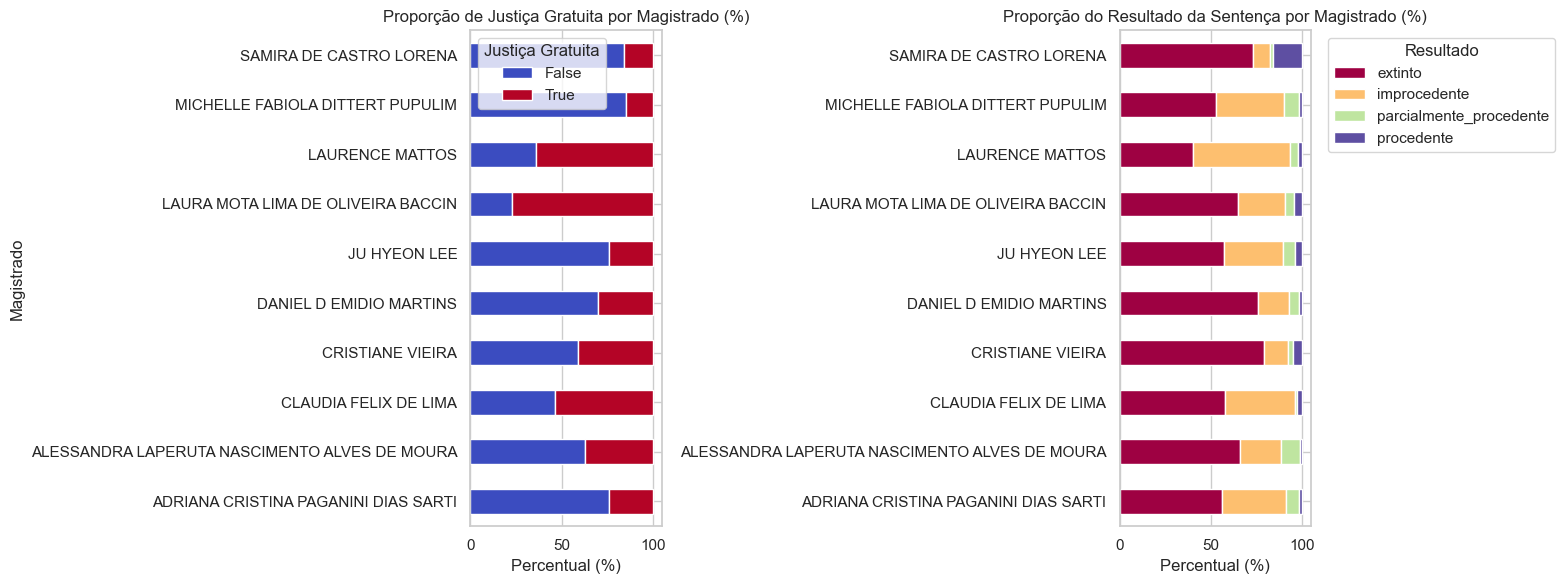

In [25]:
# Filtra os 10 magistrados com mais processos
top_magistrados = df["magistrado"].value_counts().head(10).index
df_top_magistrados = df[df["magistrado"].isin(top_magistrados)]

# Prepara a figura
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

if "tem_justica_gratuita" in df.columns:
    # Agrupamento de Justiça Gratuita por Magistrado (percentual)
    cross_jg = pd.crosstab(df_top_magistrados["magistrado"], df_top_magistrados["tem_justica_gratuita"], normalize="index") * 100
    cross_jg.plot(kind="barh", stacked=True, ax=ax[0], colormap="coolwarm")
    ax[0].set_title("Proporção de Justiça Gratuita por Magistrado (%)")
    ax[0].set_xlabel("Percentual (%)")
    ax[0].set_ylabel("Magistrado")
    ax[0].legend(title="Justiça Gratuita")

if "resultado_sentenca" in df.columns:
    # Focar apenas nos resultados conhecidos
    df_resultados_conhecidos = df_top_magistrados[df_top_magistrados["resultado_sentenca"] != "nao_identificado"]
    if not df_resultados_conhecidos.empty:
        cross_res = pd.crosstab(df_resultados_conhecidos["magistrado"], df_resultados_conhecidos["resultado_sentenca"], normalize="index") * 100
        cross_res.plot(kind="barh", stacked=True, ax=ax[1], colormap="Spectral")
        ax[1].set_title("Proporção do Resultado da Sentença por Magistrado (%)")
        ax[1].set_xlabel("Percentual (%)")
        ax[1].set_ylabel("")
        ax[1].legend(title="Resultado", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 3. Mapa de Calor (Heatmap): Assunto vs Resultado da Sentença
Identificando visualmente a correlação entre os assuntos mais demandados e a tendência de resultado das decisões.

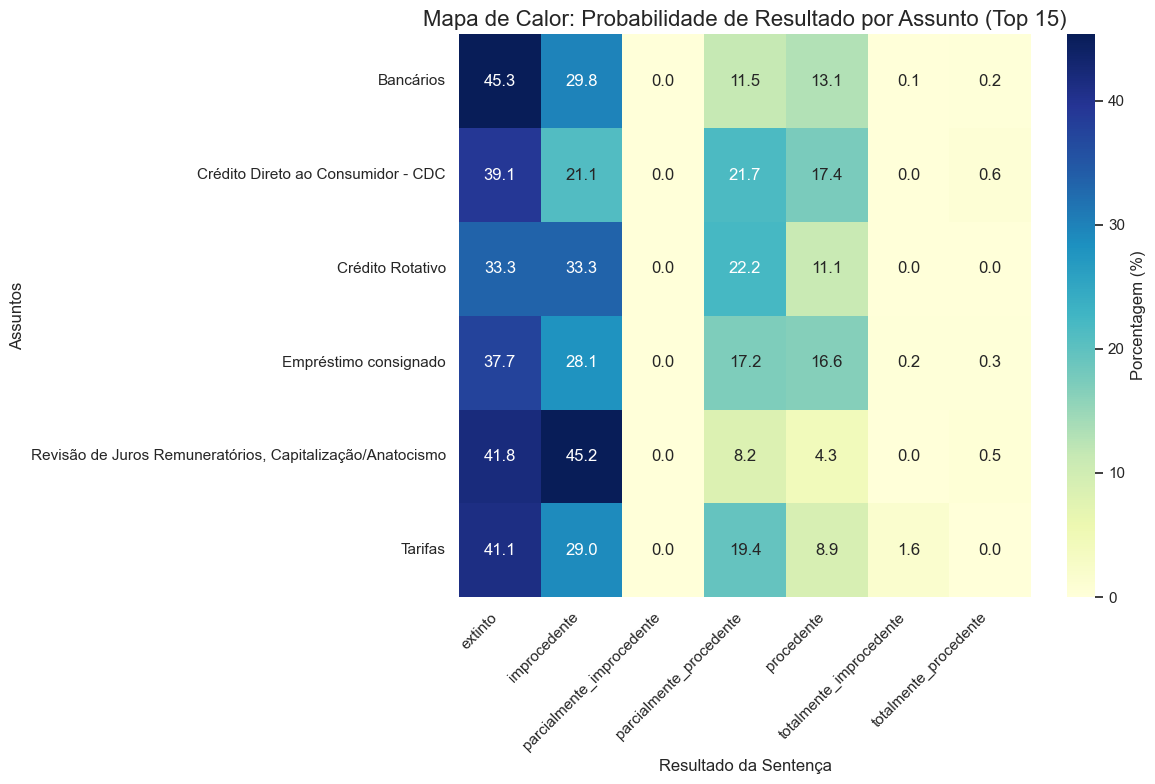

In [26]:
coluna_ass = "assunto" if "assunto" in df.columns else "assuntos"

if coluna_ass in df.columns and "resultado_sentenca" in df.columns:
    # Filtra os top 15 assuntos para o heatmap não ficar gigantesco
    top_assuntos = df[coluna_ass].value_counts().head(15).index
    df_heat = df[(df[coluna_ass].isin(top_assuntos)) & (df["resultado_sentenca"] != "nao_identificado")]
    
    if not df_heat.empty:
        # Cria a tabela cruzada (normalizando pelas linhas - assuntos)
        heat_data = pd.crosstab(df_heat[coluna_ass], df_heat["resultado_sentenca"], normalize='index') * 100
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(heat_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Porcentagem (%)'})
        plt.title("Mapa de Calor: Probabilidade de Resultado por Assunto (Top 15)", fontsize=16)
        plt.ylabel("Assuntos")
        plt.xlabel("Resultado da Sentença")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("Dados insuficientes para gerar o heatmap cruzando assuntos e resultados encontrados.")

## 4. Análise Geográfica/Estrutural: O Impacto dos Foros
Avaliando a distribuição de resultados com base nos Fóruns onde os casos tramitaram.

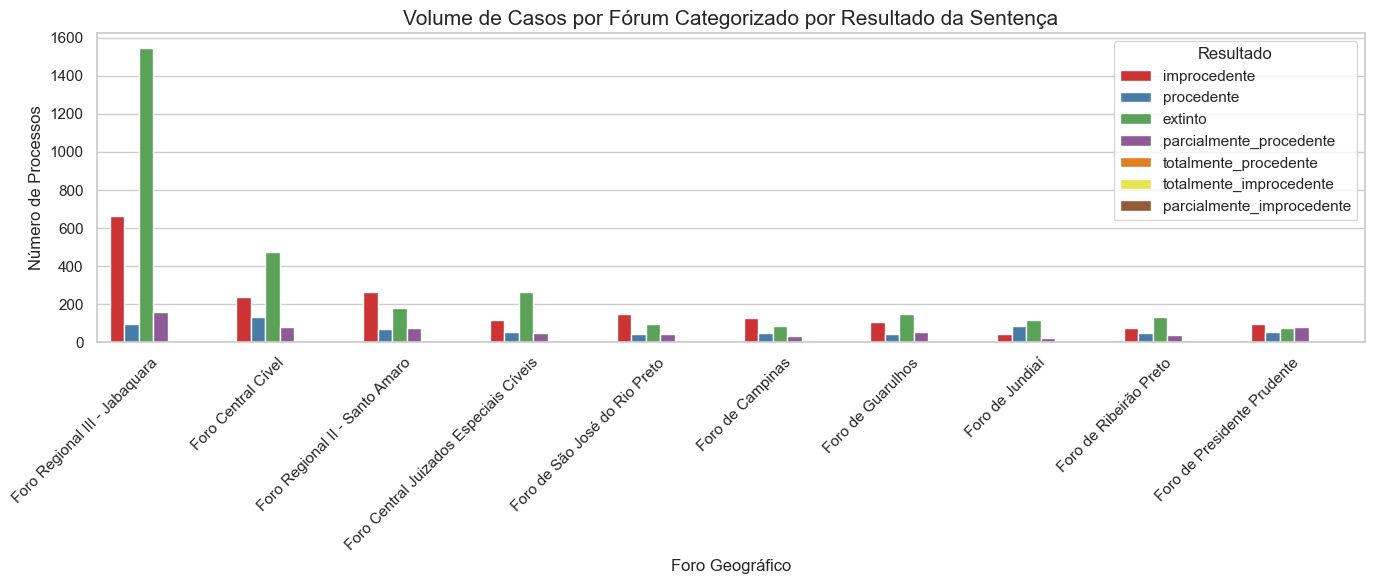

In [27]:
if "foro" in df.columns and "resultado_sentenca" in df.columns:
    top_foros = df["foro"].value_counts().head(10).index
    df_foros = df[(df["foro"].isin(top_foros)) & (df["resultado_sentenca"] != "nao_identificado")]
    
    if not df_foros.empty:
        plt.figure(figsize=(14, 6))
        # Contagem Absoluta para ver o volume
        sns.countplot(data=df_foros, x="foro", hue="resultado_sentenca", palette="Set1", order=top_foros)
        plt.title("Volume de Casos por Fórum Categorizado por Resultado da Sentença", fontsize=15)
        plt.xlabel("Foro Geográfico")
        plt.ylabel("Número de Processos")
        plt.xticks(rotation=45, ha="right")
        plt.legend(title="Resultado")
        plt.tight_layout()
        plt.show()

## 5. Mineração de Texto e Wordcloud (Nuvem de Palavras)
Analisando o vocabulário predominante das sentenças que foram dadas como **PROCEDENTES** e **IMPROCEDENTES**. *(Requer a biblioteca `wordcloud` instalada)*

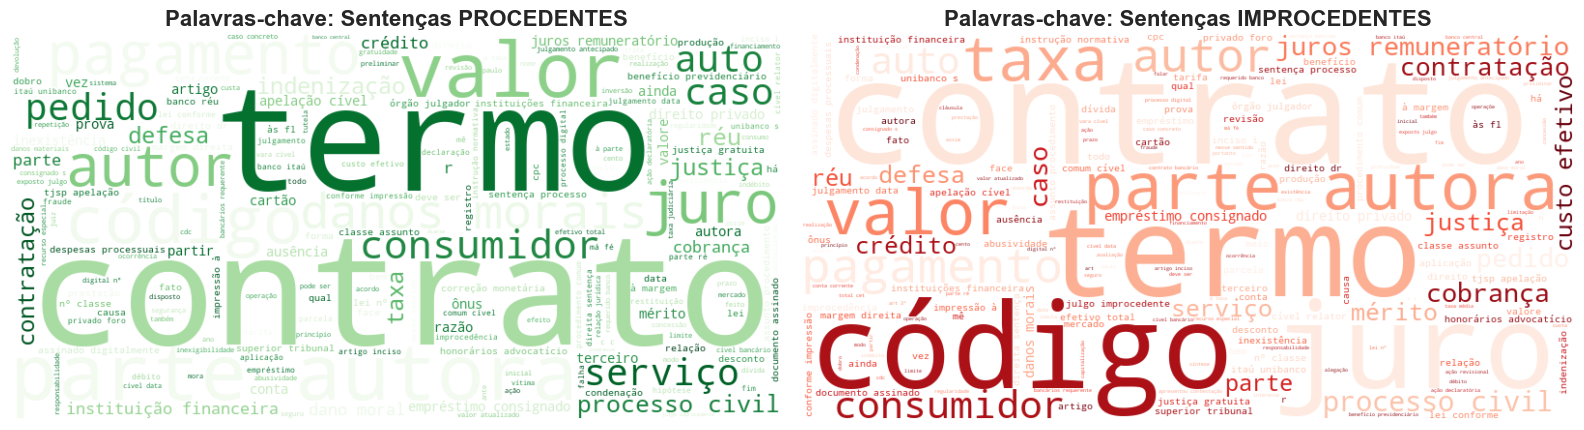

In [30]:
# Tenta importar a biblioteca, instrui como instalar se não achar
try:
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    
    coluna_decisao = "decisao"
    
    if coluna_decisao in df.columns and "resultado_sentenca" in df.columns:
        # Palavras ignoradas por não terem significado jurídico/relevância (stopwords básicas pt-br)
        stopwords = set(["que", "o", "a", "e", "de", "do", "da", "em", "para", "com", "não", "uma", "um", "no", "na", 
                         "dos", "das", "os", "as", "se", "por", "como", "mais", "ao", "aos", "ou", "foi", "pelo", "pela",
                         "nos", "nas", "sua", "seu", "já", "sobre", "são", "ao", "aos"])
        
        # Filtra os dois principais grandes grupos
        texto_procedentes = " ".join(str(v).lower() for v in df[df["resultado_sentenca"].str.contains("procedente", na=False)][coluna_decisao])
        texto_improcedentes = " ".join(str(v).lower() for v in df[df["resultado_sentenca"] == "improcedente"][coluna_decisao])
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        # Nuvem: PROCEDENTES
        if texto_procedentes.strip():
            wc_proc = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords, colormap="Greens").generate(texto_procedentes)
            axes[0].imshow(wc_proc, interpolation="bilinear")
            axes[0].set_title("Palavras-chave: Sentenças PROCEDENTES", fontsize=16, fontweight='bold')
            axes[0].axis('off')
        else:
            axes[0].text(0.5, 0.5, 'Sem dados', fontsize=20, ha='center')
            axes[0].axis('off')
            
        # Nuvem: IMPROCEDENTES
        if texto_improcedentes.strip():
            wc_imp = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords, colormap="Reds").generate(texto_improcedentes)
            axes[1].imshow(wc_imp, interpolation="bilinear")
            axes[1].set_title("Palavras-chave: Sentenças IMPROCEDENTES", fontsize=16, fontweight='bold')
            axes[1].axis('off')
        else:
            axes[1].text(0.5, 0.5, 'Sem dados', fontsize=20, ha='center')
            axes[1].axis('off')
            
        plt.tight_layout()
        plt.show()

except ImportError:
    print("A biblioteca 'wordcloud' não está instalada no seu ambiente.")
    print("Por favor, execute o comando abaixo em um terminal ou crie uma célula e rode:")
    print("!pip install wordcloud")
    print("\nE após a instalação, rode esta célula novamente.")

In [29]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\danil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
